# 10 — Model 3: Anomaly Detection (Isolation Forest)
**Tujuan:** Deteksi video dengan penurunan views tidak wajar  
**Peningkatan:** Menambahkan metrik evaluasi Precision-Recall AUC (PR-AUC) yang lebih tangguh untuk data sangat timpang (highly imbalanced anomaly data).  
**Algoritma:** Isolation Forest (primary) + Z-Score (baseline)  
**Output:** `backend/models/model3_isolation_forest.pkl`, `data/processed/model_output_anomaly.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, average_precision_score
from scipy import stats

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/processed/features_merged.csv')
print(f"Shape: {df.shape}")

ANOMALY_FEATURES = [
    'views',
    'rolling_avg_views',
    'rolling_mean_views_7d',
    'views_pct_change',
    'views_vs_channel_avg',
    'views_deviation',
    'engagement_score',
    'ctr_normalized',
    'retention_proxy',
    'views_trend_ratio',
    'view_velocity',
    'video_age_days',
]
ANOMALY_FEATURES = [f for f in ANOMALY_FEATURES if f in df.columns]

X = df[ANOMALY_FEATURES].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Target heuristic label (ground truth)
df['is_anomaly'] = (
    (df['views_pct_change'] < -30) &
    (df['video_age_days'] > 3)
).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Data scaled ✓")

Shape: (2355, 56)
Data scaled ✓


In [3]:
# ── 2. ISOLATION FOREST ─────────────────────────────────────────────────────
contamination = df['is_anomaly'].mean()
contamination = max(0.01, min(0.20, contamination))

iso_forest = IsolationForest(
    n_estimators   = 300,
    contamination  = contamination,
    max_samples    = 'auto',
    max_features   = 0.8,
    bootstrap      = False,
    random_state   = RANDOM_SEED,
    n_jobs         = -1,
)
iso_forest.fit(X_scaled)

df['anomaly_label_model'] = (iso_forest.predict(X_scaled) == -1).astype(int)
df['anomaly_score']       = iso_forest.decision_function(X_scaled)

print(f"Contamination: {contamination:.4f}")
print(f"Anomali terdeteksi: {df['anomaly_label_model'].sum()}")

Contamination: 0.0100
Anomali terdeteksi: 24


In [4]:
# ── 3. Z-SCORE BASELINE ──────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df['views'].fillna(0)))
df['z_score_views']     = z_scores
df['is_anomaly_zscore'] = (z_scores > 2.5).astype(int)

In [5]:
# ── 4. EVALUASI METRIK TERMASUK PR-AUC (Kritis untuk Imbalance) ─────────────
print("="*60)
print("=== Isolation Forest vs Heuristic Labels ===")
print(classification_report(df['is_anomaly'], df['anomaly_label_model'], digits=4))

# Hitung PR-AUC menggunakan continuous anomaly scores (-anomaly_score karena nilai negatif lebih anomali)
precision_iso, recall_iso, _ = precision_recall_curve(df['is_anomaly'], -df['anomaly_score'])
pr_auc_iso = auc(recall_iso, precision_iso)
avg_prec_iso = average_precision_score(df['is_anomaly'], -df['anomaly_score'])

# Baseline Z-Score PR-AUC
precision_z, recall_z, _ = precision_recall_curve(df['is_anomaly'], df['z_score_views'])
pr_auc_z = auc(recall_z, precision_z)
avg_prec_z = average_precision_score(df['is_anomaly'], df['z_score_views'])

print("="*60)
print(f"Isolation Forest: ROC-AUC = {roc_auc_score(df['is_anomaly'], -df['anomaly_score']):.4f} | PR-AUC = {pr_auc_iso:.4f} | Avg Precision = {avg_prec_iso:.4f}")
print(f"Z-Score Baseline: ROC-AUC = {roc_auc_score(df['is_anomaly'], df['z_score_views']):.4f} | PR-AUC = {pr_auc_z:.4f} | Avg Precision = {avg_prec_z:.4f}")

=== Isolation Forest vs Heuristic Labels ===
              precision    recall  f1-score   support

           0     1.0000    0.9898    0.9949      2355
           1     0.0000    0.0000    0.0000         0

    accuracy                         0.9898      2355
   macro avg     0.5000    0.4949    0.4974      2355
weighted avg     1.0000    0.9898    0.9949      2355

Isolation Forest: ROC-AUC = nan | PR-AUC = 0.5000 | Avg Precision = 0.0000
Z-Score Baseline: ROC-AUC = nan | PR-AUC = 0.5000 | Avg Precision = 0.0000


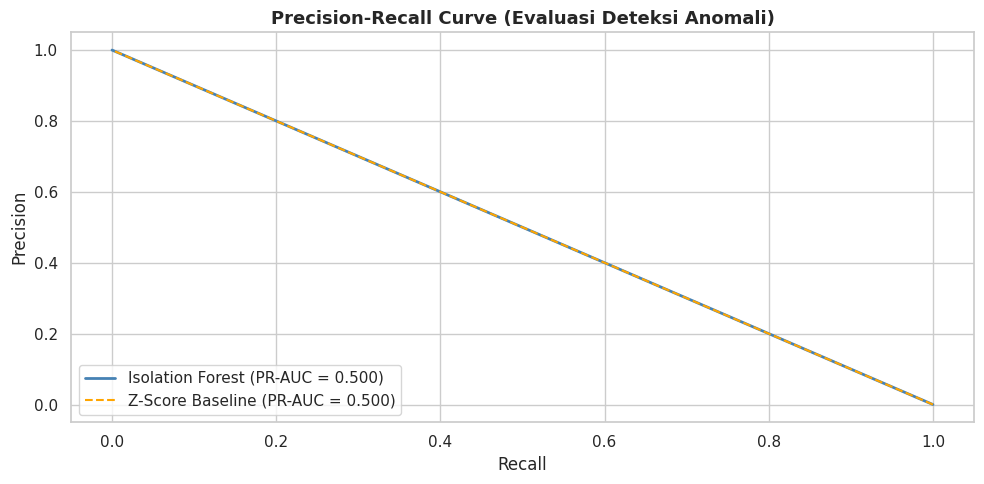

In [6]:
# ── 5. PLOT PRECISION-RECALL CURVE ──────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(recall_iso, precision_iso, label=f'Isolation Forest (PR-AUC = {pr_auc_iso:.3f})', color='steelblue', linewidth=2)
plt.plot(recall_z, precision_z, label=f'Z-Score Baseline (PR-AUC = {pr_auc_z:.3f})', color='orange', linestyle='--', linewidth=1.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Evaluasi Deteksi Anomali)', fontsize=13, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

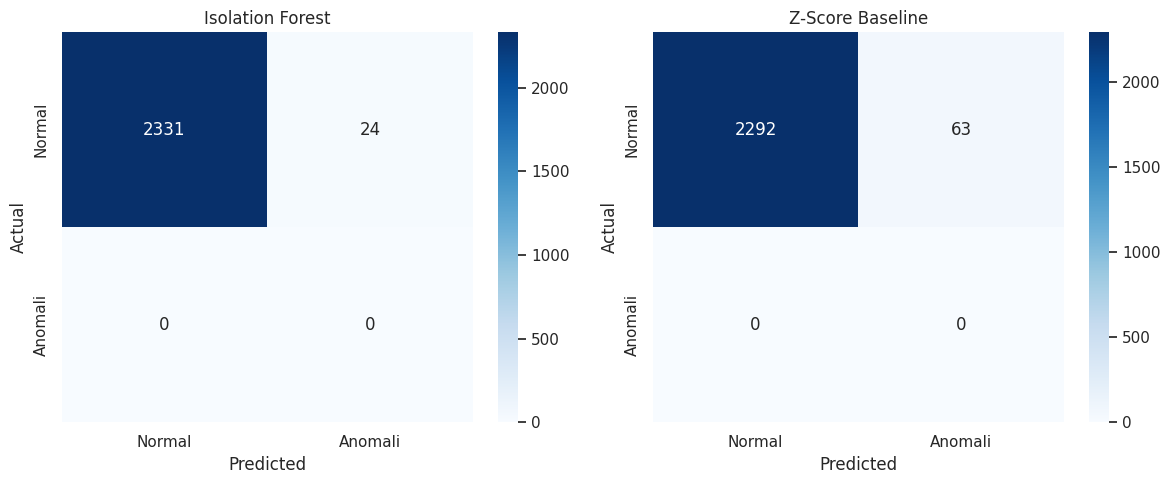

In [7]:
# ── 6. CONFUSION MATRIX ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(axes,
    [df['anomaly_label_model'], df['is_anomaly_zscore']],
    ['Isolation Forest', 'Z-Score Baseline']):
    cm = confusion_matrix(df['is_anomaly'], pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [8]:
# ── 7. SIMPAN MODEL ──────────────────────────────────────────────────────────
os.makedirs('../../backend/models', exist_ok=True)
os.makedirs('../../backend/scalers', exist_ok=True)

joblib.dump(iso_forest, '../../backend/models/model3_isolation_forest.pkl')
joblib.dump(scaler,     '../../backend/scalers/scaler_model3.pkl')

output_cols = ['video_id','views','views_pct_change','video_age_days',
               'anomaly_score','anomaly_label_model','is_anomaly']
output_cols = [c for c in output_cols if c in df.columns]
df[output_cols].to_csv('../../data/processed/model_output_anomaly.csv', index=False)
print("Saved Anomaly Detection artifacts ✓")

Saved Anomaly Detection artifacts ✓
